In [1]:
%load_ext autoreload
%autoreload 2

## REMEMBER I NEED TO CHANGE THE NPX CHANNEL AND PATCH SAMPLING RATE FOR EACH CELL!!!!

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))


from spikeparam.patch.fit import Spike
from spikeparam.patch.fit import SpikeGroup

import spec_decomp_and_param  



from neurodsp import spectral

from scipy import signal
import scipy

import h5py
from tqdm.notebook import tqdm

import numpy as np
import pandas as pd

from neurodsp import filt
from neurodsp.timefrequency import amp_by_time, phase_by_time
from neurodsp.plts import plot_time_series, plot_instantaneous_measure
from neurodsp.plts.time_series import plot_bursts
from neurodsp.burst import detect_bursts_dual_threshold, compute_burst_stats

from scipy.signal import sosfiltfilt, butter

from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
import statsmodels.api as sm
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
import scipy.stats as stats
import scipy.spatial as sp_spatial
from scipy.stats import ttest_ind

import os
import time


from fooof import FOOOF


from sklearn.linear_model import LinearRegression

sns.set(rc={'figure.figsize':(12,9)})
sns.set_style('whitegrid')
sns.set_style("whitegrid", {'axes.grid' : False})


import warnings

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spec_decomp_and_param.py:11: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  import fooof


### HELPER FUNCTIONS - to do: move to .py file 

In [3]:
def butter_bandpass(data, fs, filt_freq, order):
    # make sure that the user provides two frequencies for bandpass filter
    try:
        # renormalize frequencies in Hz to fractional scale required by butter
        nyq = 0.5 * fs # nyquist frequency
        f0 = (filt_freq[0]/nyq)
        f1 = (filt_freq[1]/nyq)

        # highpass first
        sos = butter(order, f0, btype = 'high', analog=False, output='sos')
        y = sosfiltfilt(sos, data)

        # then lowpass
        sos = butter(order, f1, btype = 'low', analog=False, output='sos')
        y = sosfiltfilt(sos, y)
        
        return y
    
    except:
        print("filt_freq must have two frequencies for a bandpass filter")

In [4]:
def in_burst_to_burst_range_ms(is_burst_array, ms_convert=True):

    """Convert boolean array of whether each idx is in burst, to range of bursts in ms"""

    s = pd.Series(is_burst_array)
    grp = s.eq(False).cumsum()
    arr = grp.loc[s.eq(True)] \
             .groupby(grp) \
             .apply(lambda x: [x.index.min(), x.index.max()])
    
    if ms_convert:
        arr = [[i[0] / lfp_one_ms, i[1] / lfp_one_ms] for i in arr.values]
    else:
        arr = arr.values
    
    
    
    return arr
    

In [5]:
def upper(df):
    '''Returns the upper triangle of a correlation matrix.
    You can use scipy.spatial.distance.squareform to recreate matrix from upper triangle.
    Args:
      df: pandas or numpy correlation matrix
    Returns:
      list of values from upper triangle
    '''
    try:
        assert(type(df)==np.ndarray)
    except:
        if type(df)==pd.DataFrame:
            df = df.values
        else:
            raise TypeError('Must be np.ndarray or pd.DataFrame')
    mask = np.triu_indices(df.shape[0], k=1)
    return df[mask]

In [6]:
def spk_lfp_class(spk_times_ms, ranges_not_burst_low_ms, gamma_bursts_ms):
    """Classify spikes based on whether they occur during LFP gamma burst 
    or not during gamma oscillations """
    spk_class = []
    spk_idx = []
    spk_idx_ms = []

    for counter, spk in enumerate(spk_times_ms):
        found = False

        for no_burst in ranges_not_burst_low_ms:
            if no_burst[0] <= spk <= no_burst[1]:
                found = True
                spk_class.append('no_gamma')
                spk_idx_ms.append(spk)
                spk_idx.append(counter)
                break

        if not found:
            for burst in gamma_bursts_ms:
                if burst[0] <= spk <= burst[1]:
                    found = True
                    spk_class.append('gamma')
                    spk_idx_ms.append(spk)
                    spk_idx.append(counter)
                    break

    return spk_class, spk_idx, spk_idx_ms

In [7]:
def get_lowest_analytical_amp(gamma_amp, ranges_not_burst, one_ms, thresh=0.25):
    
    no_burst_mean_amp = []
    no_burst_mean_ranges = []

    for r in ranges_not_burst:

        am_range = gamma_amp[slice(*r)]
        #take mean of analytic amplitude for that range 
        mean_am = np.nanmean(am_range)
        no_burst_mean_amp.append(mean_am)
        no_burst_mean_ranges.append(r)
        
    #Select 25% (default) no burst sections with lowest analytical amplitude 
    n_lowest = int(len(no_burst_mean_amp) * thresh)
    no_burst_mean_amp_array = np.array(no_burst_mean_amp, dtype=np.float32)
    lowest_amp_no_bursts = no_burst_mean_amp_array.argsort()[:n_lowest]

    #get the index range of the sections with lowest amplitude 
    ranges_not_burst_low =  [ranges_not_burst[i] for i in lowest_amp_no_bursts]

    #convert to ms
    ranges_not_burst_low_ms = [(x/one_ms, y/one_ms) for x,y in ranges_not_burst_low]
    
    return ranges_not_burst_low_ms
    

In [8]:
def visualize_lfp_gamma_regions(lfp_times, lfp_filt, gamma_groups, no_gamma_groups,title=None, xlim=None, plot_spk=False, spk_gamma=None, spk_nogamma=None):
    plt.plot(lfp_times, lfp_filt, label="LFP", color='black')
    #loop through gamma groups
    plt.axvspan(gamma_groups[0][0], gamma_groups[0][1], alpha=0.3, color="firebrick", label="gamma burst")
    for g in gamma_groups[1:]:
        plt.axvspan(g[0], g[1], alpha=0.3, color="firebrick")

    #loop through non gamma groups
    plt.axvspan(no_gamma_groups[0][0], no_gamma_groups[0][1], alpha=0.3, color="royalblue", label="not gamma burst")
    for ng in no_gamma_groups[1:]:
        plt.axvspan(ng[0], ng[1], alpha=0.3, color="royalblue")
    
    plt.xlabel('Time (ms)')
    plt.ylabel('Voltage (mV)')
    if xlim ==None:
        plt.title(title + " full recording")
        if plot_spk:
            plt.eventplot(spk_gamma,lineoffsets = 80, linelengths=10, color='darkred', label = 'gamma spikes')
            plt.eventplot(spk_nogamma,lineoffsets = 80, linelengths=10,color = 'darkblue', label = 'no gamma spikes')
            
        plt.legend(loc="lower left")
        plt.show()
    else:
        plt.xlim(xlim)
        plt.title(title + " from " +str(xlim[0])+ " ms to " + str(xlim[1]) + " ms")
        if plot_spk:
            plt.eventplot(spk_gamma,lineoffsets = 80, linelengths=10, color='darkred', label = 'gamma spikes')
            plt.eventplot(spk_nogamma,lineoffsets = 80, linelengths=10,color = 'darkblue', label = 'no gamma spikes')
        plt.legend(loc="lower left")
        

In [9]:
metadata_dir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Data Summary.xlsx'
patch_fs_c42 = 50023.88170476


In [10]:
npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate


npx_channels = 384


data_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/all_recordings/'

out_lfp_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/'

out_npx_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/'

out_patch_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/'

cell_ids = ['c14', 'c42']

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook 

load_spe1_data(data_path, lfp_fs, npx_fs, patch_fs, cell_ids, npx_channels, npx_patch_channel, out_lfp_path, out_npx_path, out_patch_path)



## Cell 42  (Whole patch, IC)
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 42

#### Step 0: Get loaded data

In [11]:
lfp_c42= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c42_lfp_filt.npy'
patch_c42 = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c42patch_filt.npy'


In [12]:
#get cell number 
cell_num = lfp_c42.split('/')[len(lfp_c42.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt_c42 = np.load(lfp_c42)
lfp_fs = 2500 # sampling rate
lfp_one_ms = float(lfp_fs / 1000)
lfp_times_c42 = np.arange(0, np.shape(lfp_filt_c42)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt_c42 = np.load(patch_c42)
patch_c42_one_ms = float(patch_fs_c42  / 1000)
patch_times_c42 = np.arange(0, np.shape(patch_filt_c42 )[0]) / patch_c42_one_ms # in ms instead of sec

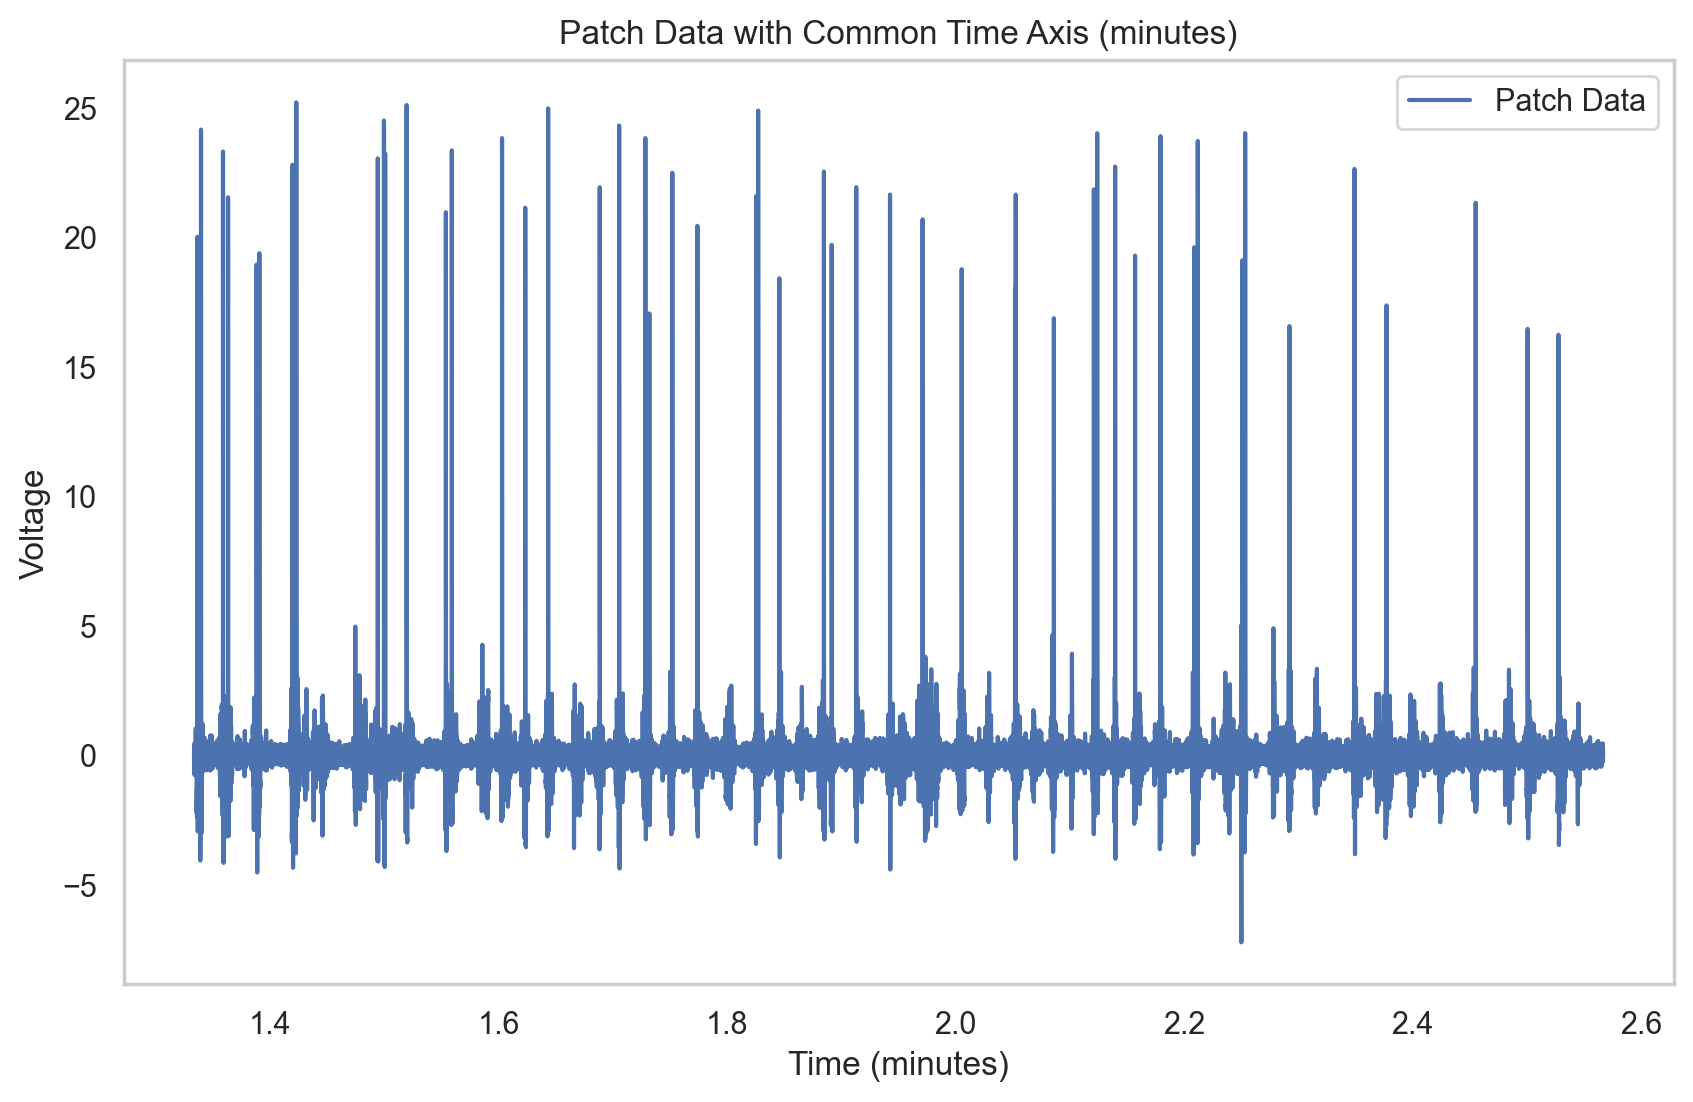

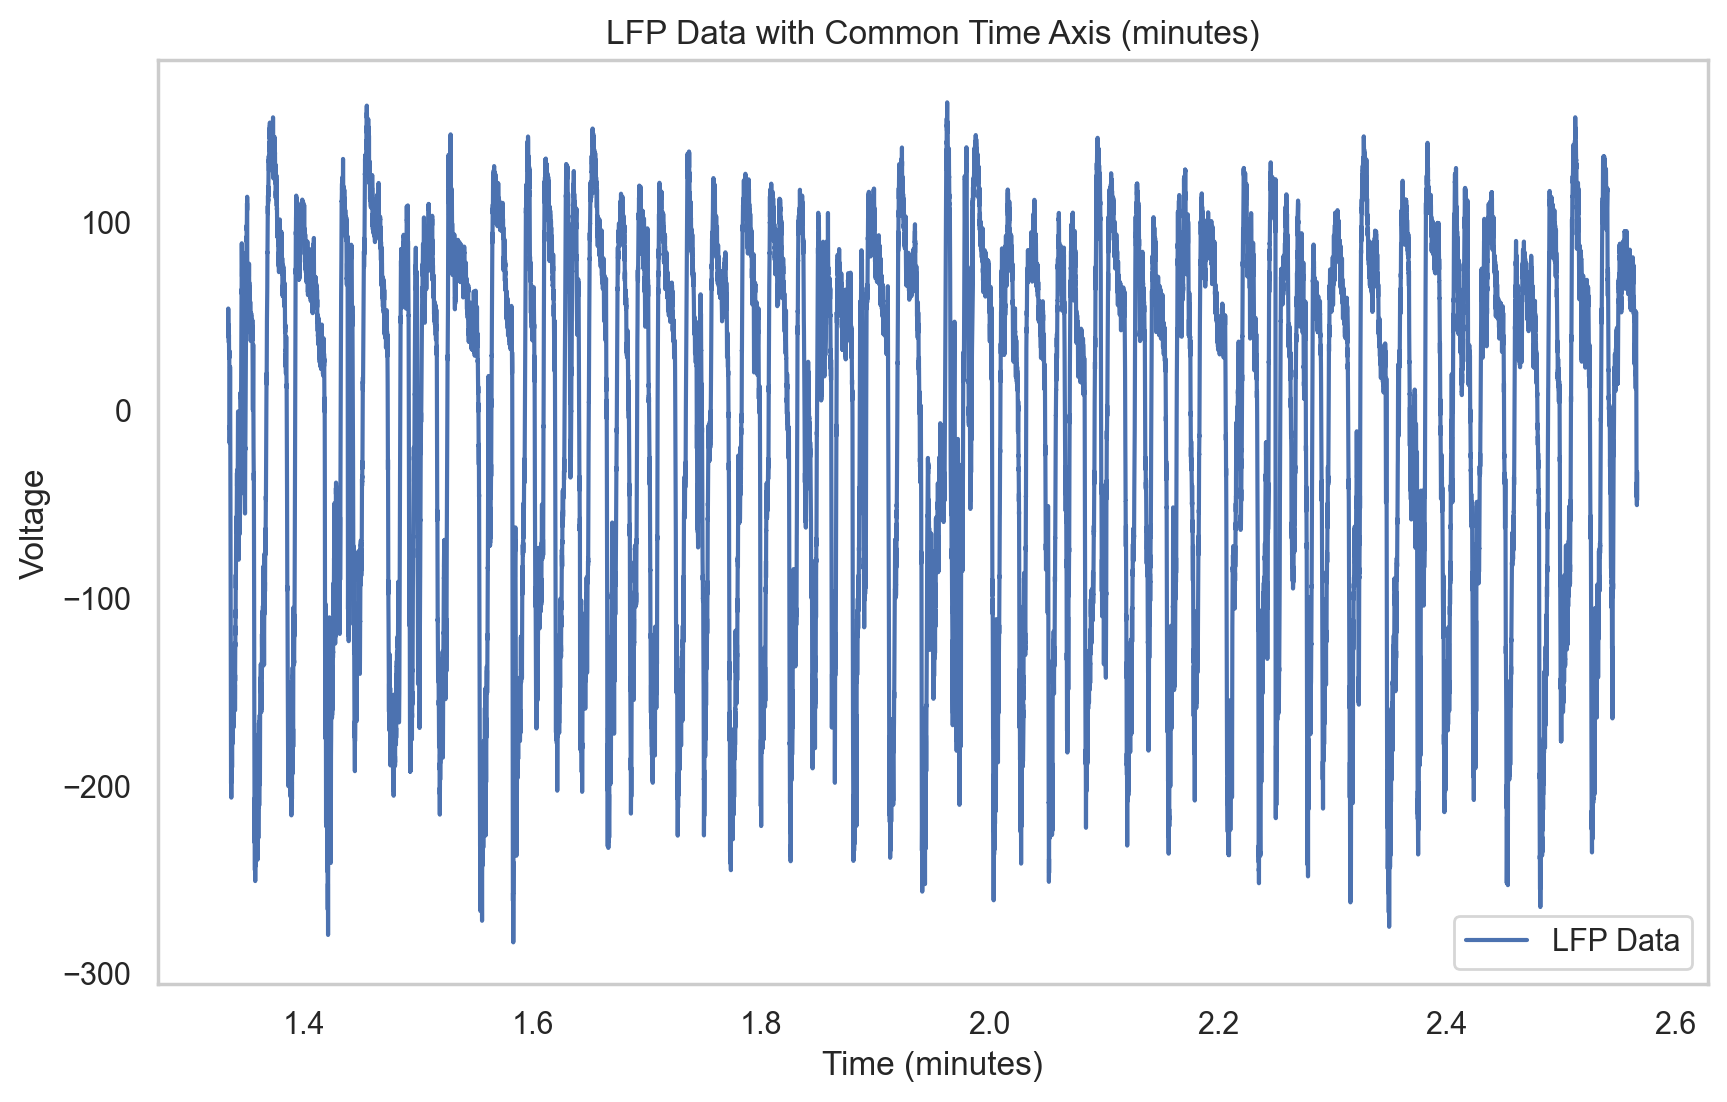

In [13]:
# Plot simultaneous patch and LFP data
# Convert time arrays to minutes
patch_times_min = patch_times_c42 / 60000  # Convert milliseconds to minutes
lfp_times_min = lfp_times_c42 / 60000  # Convert milliseconds to minutes

# Set the common time axis in minutes (e.g., from 13.3333 to 25.6667 minutes)
common_time_range_min = np.arange(80000 / 60000, 154000 / 60000, 1 / 60000)  # Adjust as needed

# Interpolate patch data onto the common time axis
patch_interp = np.interp(common_time_range_min, patch_times_min, patch_filt_c42)

# Interpolate LFP data onto the common time axis
lfp_interp = np.interp(common_time_range_min, lfp_times_min, lfp_filt_c42)

# Plot patch data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, patch_interp, label='Patch Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('Patch Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

# Plot LFP data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, lfp_interp, label='LFP Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('LFP Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

## 






STEP 1: ANALYZE LFP DATA

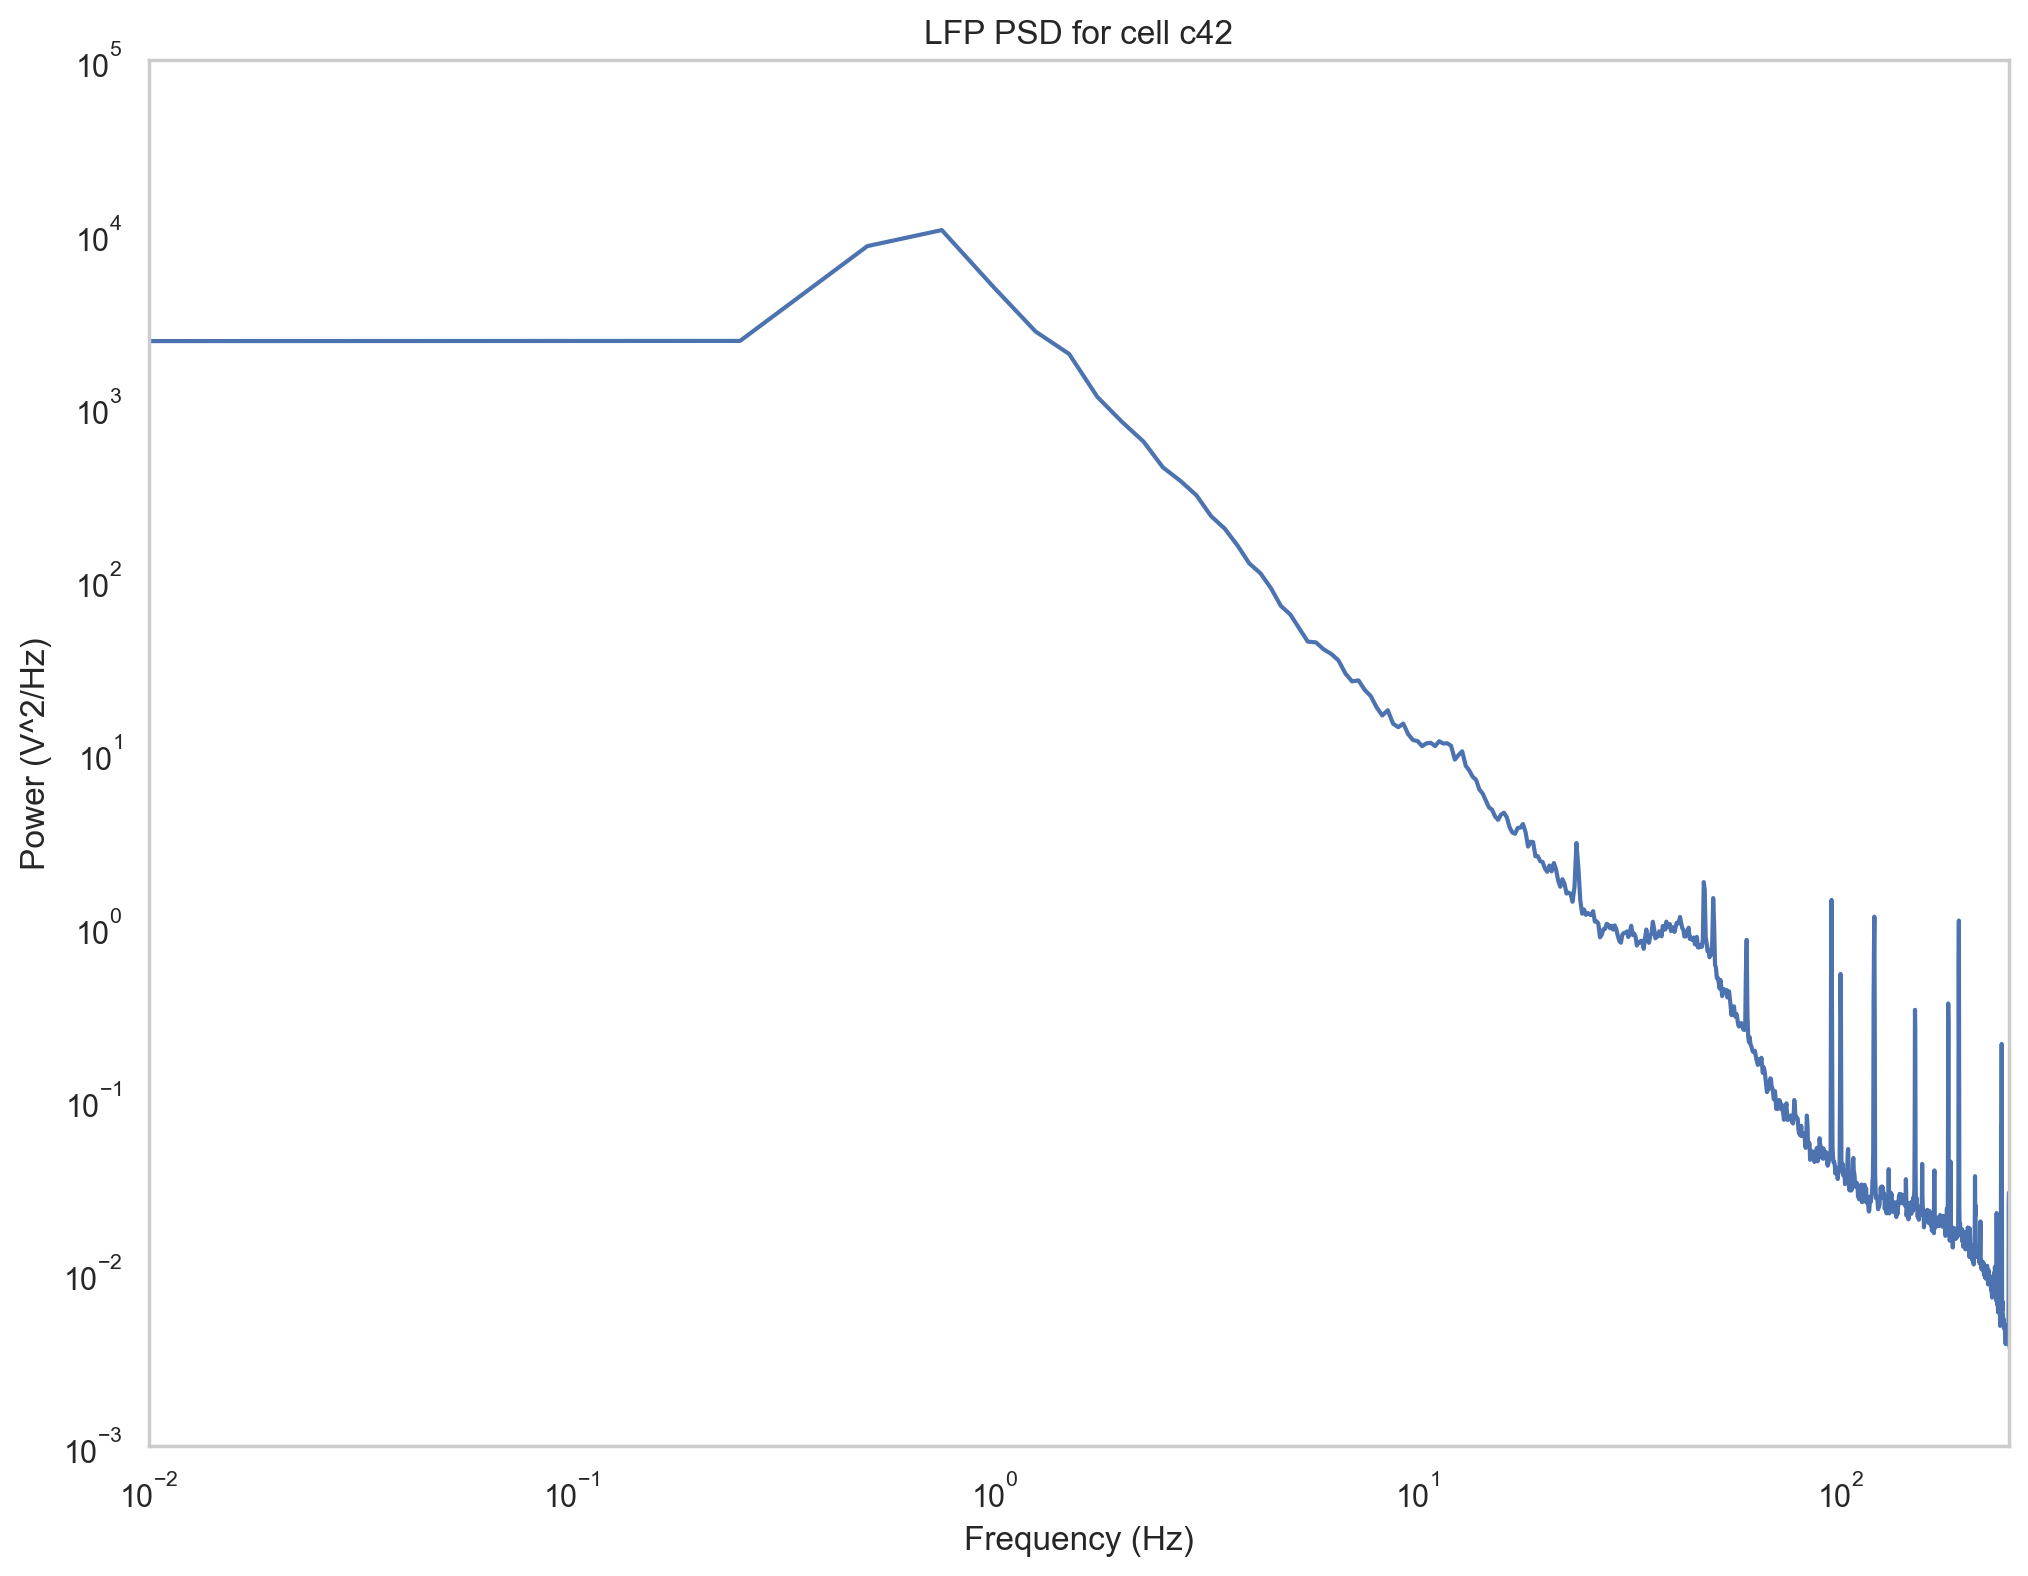

In [14]:
#plot PSD for cell 42
# plot power spectrum
fxx_c42, pxx_c42 = spectral.compute_spectrum(lfp_filt_c42, lfp_fs, method='welch', window='hann', nperseg=lfp_fs*4)

xlim = (10e-3, 250)
ylim = (10e-4, 10e4)
plt.loglog(fxx_c42, pxx_c42)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (V^2/Hz)')
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("LFP PSD for cell "+ cell_num)
plt.show()


## SLIDING WINDOWS APPROACH

In [ ]:


# Set up sliding window parameters
window_length = lfp_fs * 25  # e.g., 4 seconds
step_size = lfp_fs * 100   # e.g., 1 second step

# Initialize lists to store results
spectra = []
foof_results = []

# Loop through LFP data using a sliding window
for start in range(0, len(lfp_filt_c42) - window_length, window_length):
    # Extract the LFP segment
    lfp_segment = lfp_filt_c42[start:start + window_length]
    
    # Compute the power spectrum for the segment
    fxx, pxx = spectral.compute_spectrum(lfp_segment, lfp_fs, method='welch', window='hann', nperseg=lfp_fs*4)
    
    # Fit the FOOOF model to extract aperiodic and periodic features
    fm = FOOOF(max_n_peaks=0, verbose=False)
    fm.fit(fxx, pxx, freq_range=(5, 90))
    
    # Store results
    spectra.append((fxx, pxx))
    foof_results.append(fm)
    
    # Optional: plot the power spectrum for each segment
    plt.loglog(fxx, pxx)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power (V^2/Hz)')
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.title("LFP PSD Segment {} - {}".format(start, start + window_length))
    plt.show()




In [ ]:
foof_results

In [ ]:
foof_results[0

### Detect spikes from patch data

In [ ]:
#threshold in mVs
sp = Spike(thresh_amp=10, window_length=(5., 5.), smooth_frac=.01)


sp.fit(patch_filt_c42, patch_fs_c42, n_jobs=-1, progress=tqdm)

### Get spike times 

In [40]:
spk_times_idx = sp.spike_inds
spk_times_ms = patch_times_c42[sp.spike_inds]

In [41]:


def extract_pre_spike_lfp(lfp_data, spike_times, fs, pre_spike_window):
    """
    Extracts LFP segments before spikes and computes FOOOF features.
    
    Args:
    lfp_data (np.array): The continuous LFP signal.
    spike_times (np.array): Times of spikes in seconds.
    fs (int): Sampling frequency of LFP.
    pre_spike_window (float): Window in seconds to consider before each spike.
    
    Returns:
    DataFrame with FOOOF features for each spike.
    """
    n_samples = int(pre_spike_window * fs)
    fooof_results = []
    
    for spike_time in spike_times:
        start_sample = int((spike_time - pre_spike_window) * fs)
        end_sample = int(spike_time * fs)
        if start_sample < 0:
            continue  # Skip spikes too close to the start of recording
        
        segment = lfp_data[start_sample:end_sample]
        
        # Compute PSD
        freqs, powers = welch(segment, fs=fs, nperseg=len(segment))
        
        # Fit FOOOF model
        fm = FOOOF(max_n_peaks=6, verbose=False)
        fm.fit(freqs, powers, freq_range=(1, 100))
        
        # Extract and store features
        fooof_features = {
            'ramp_amp': fm.aperiodic_params_[0],
            'offset': fm.aperiodic_params_[1],
            'peaks': fm.peak_params_ if fm.peak_params_ else []
        }
        fooof_results.append(fooof_features)
    
    return pd.DataFrame(fooof_results)

# Example usage
pre_spike_window = 0.2  # 200 ms
lfp_fs = 1000  # Hz
spike_times = np.array([1.0, 2.0, 3.5])  # Example spike times in seconds

fooof_df = extract_pre_spike_lfp(lfp_filt_c42, spike_times, lfp_fs, pre_spike_window)


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [22]:
spike_times

array([1. , 2. , 3.5])

#### 0. Use specpram to find gamma peaks

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


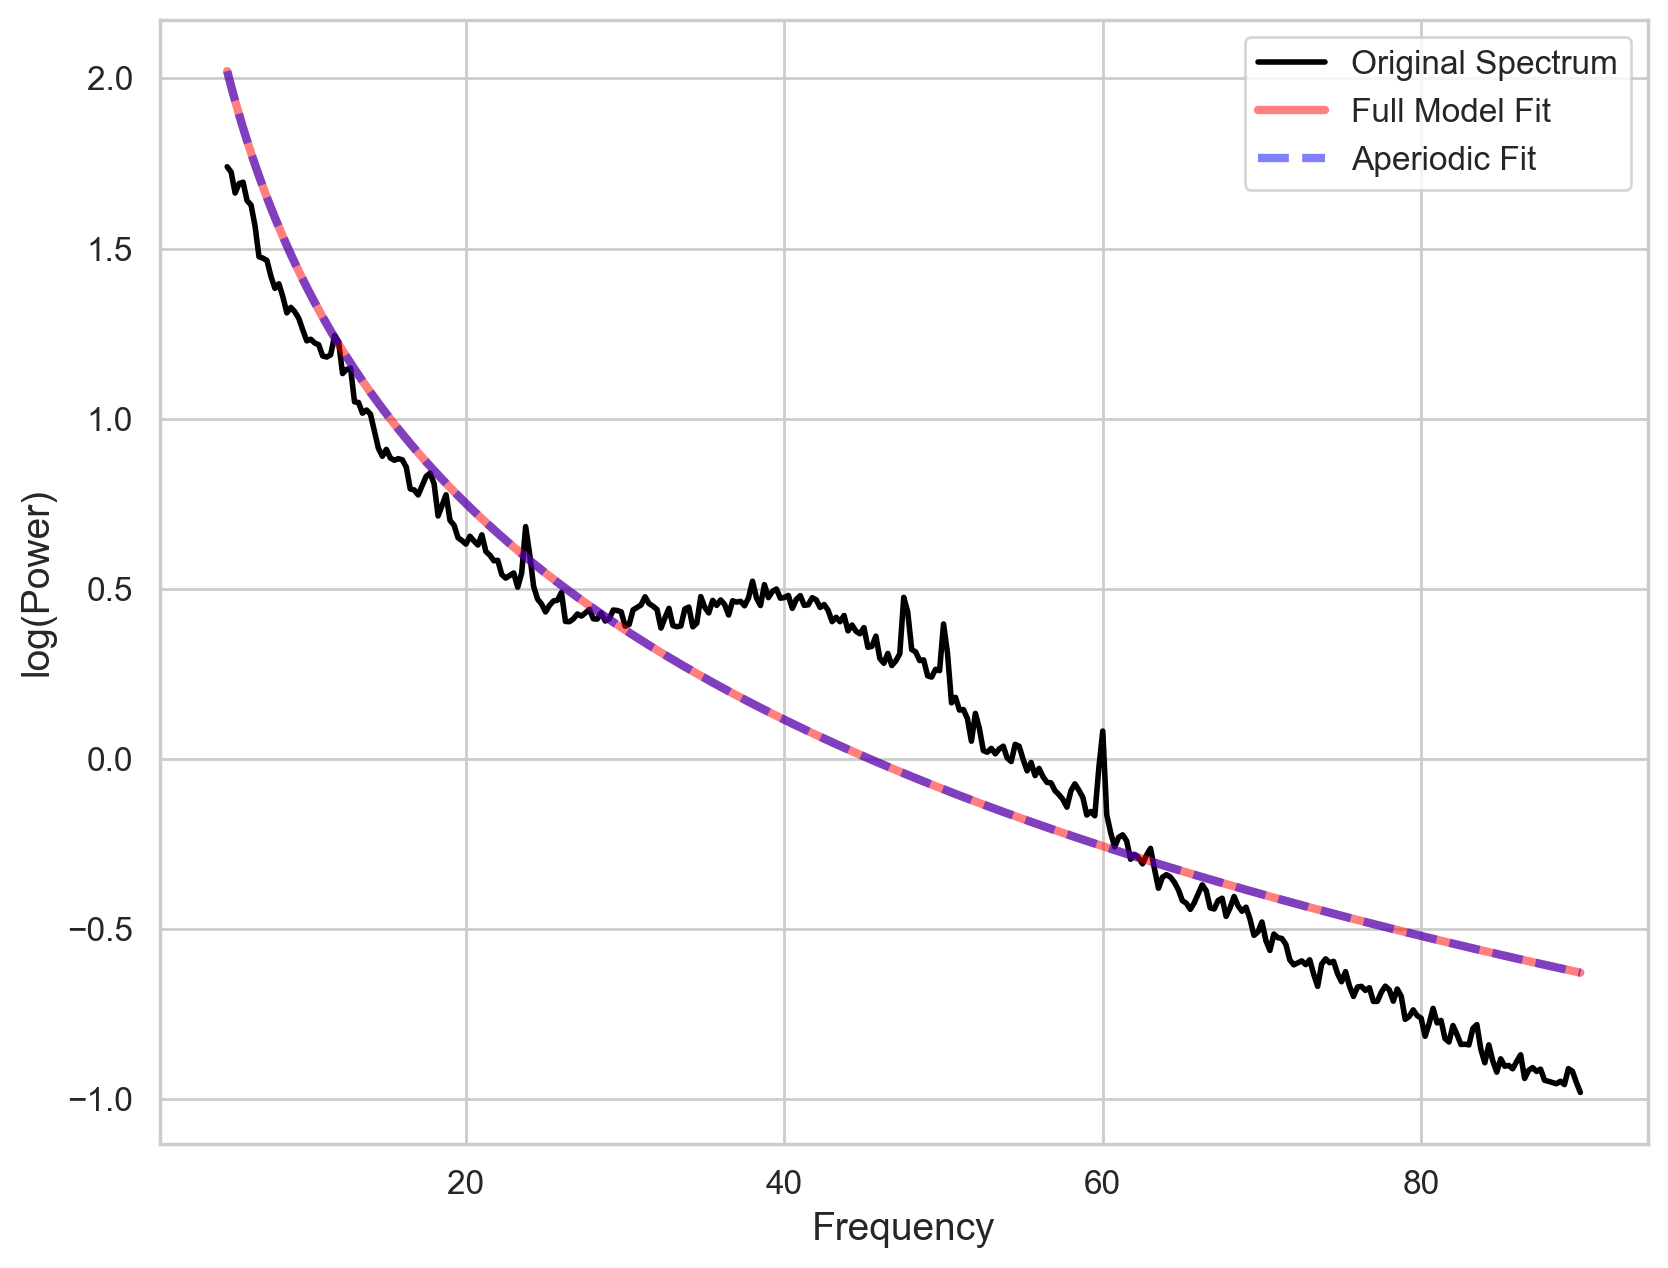

In [16]:
fm_c42 = FOOOF(max_n_peaks=0, verbose=False)
fm_c42.fit(fxx_c42, pxx_c42, freq_range=(5,90))
fm_c42.plot()

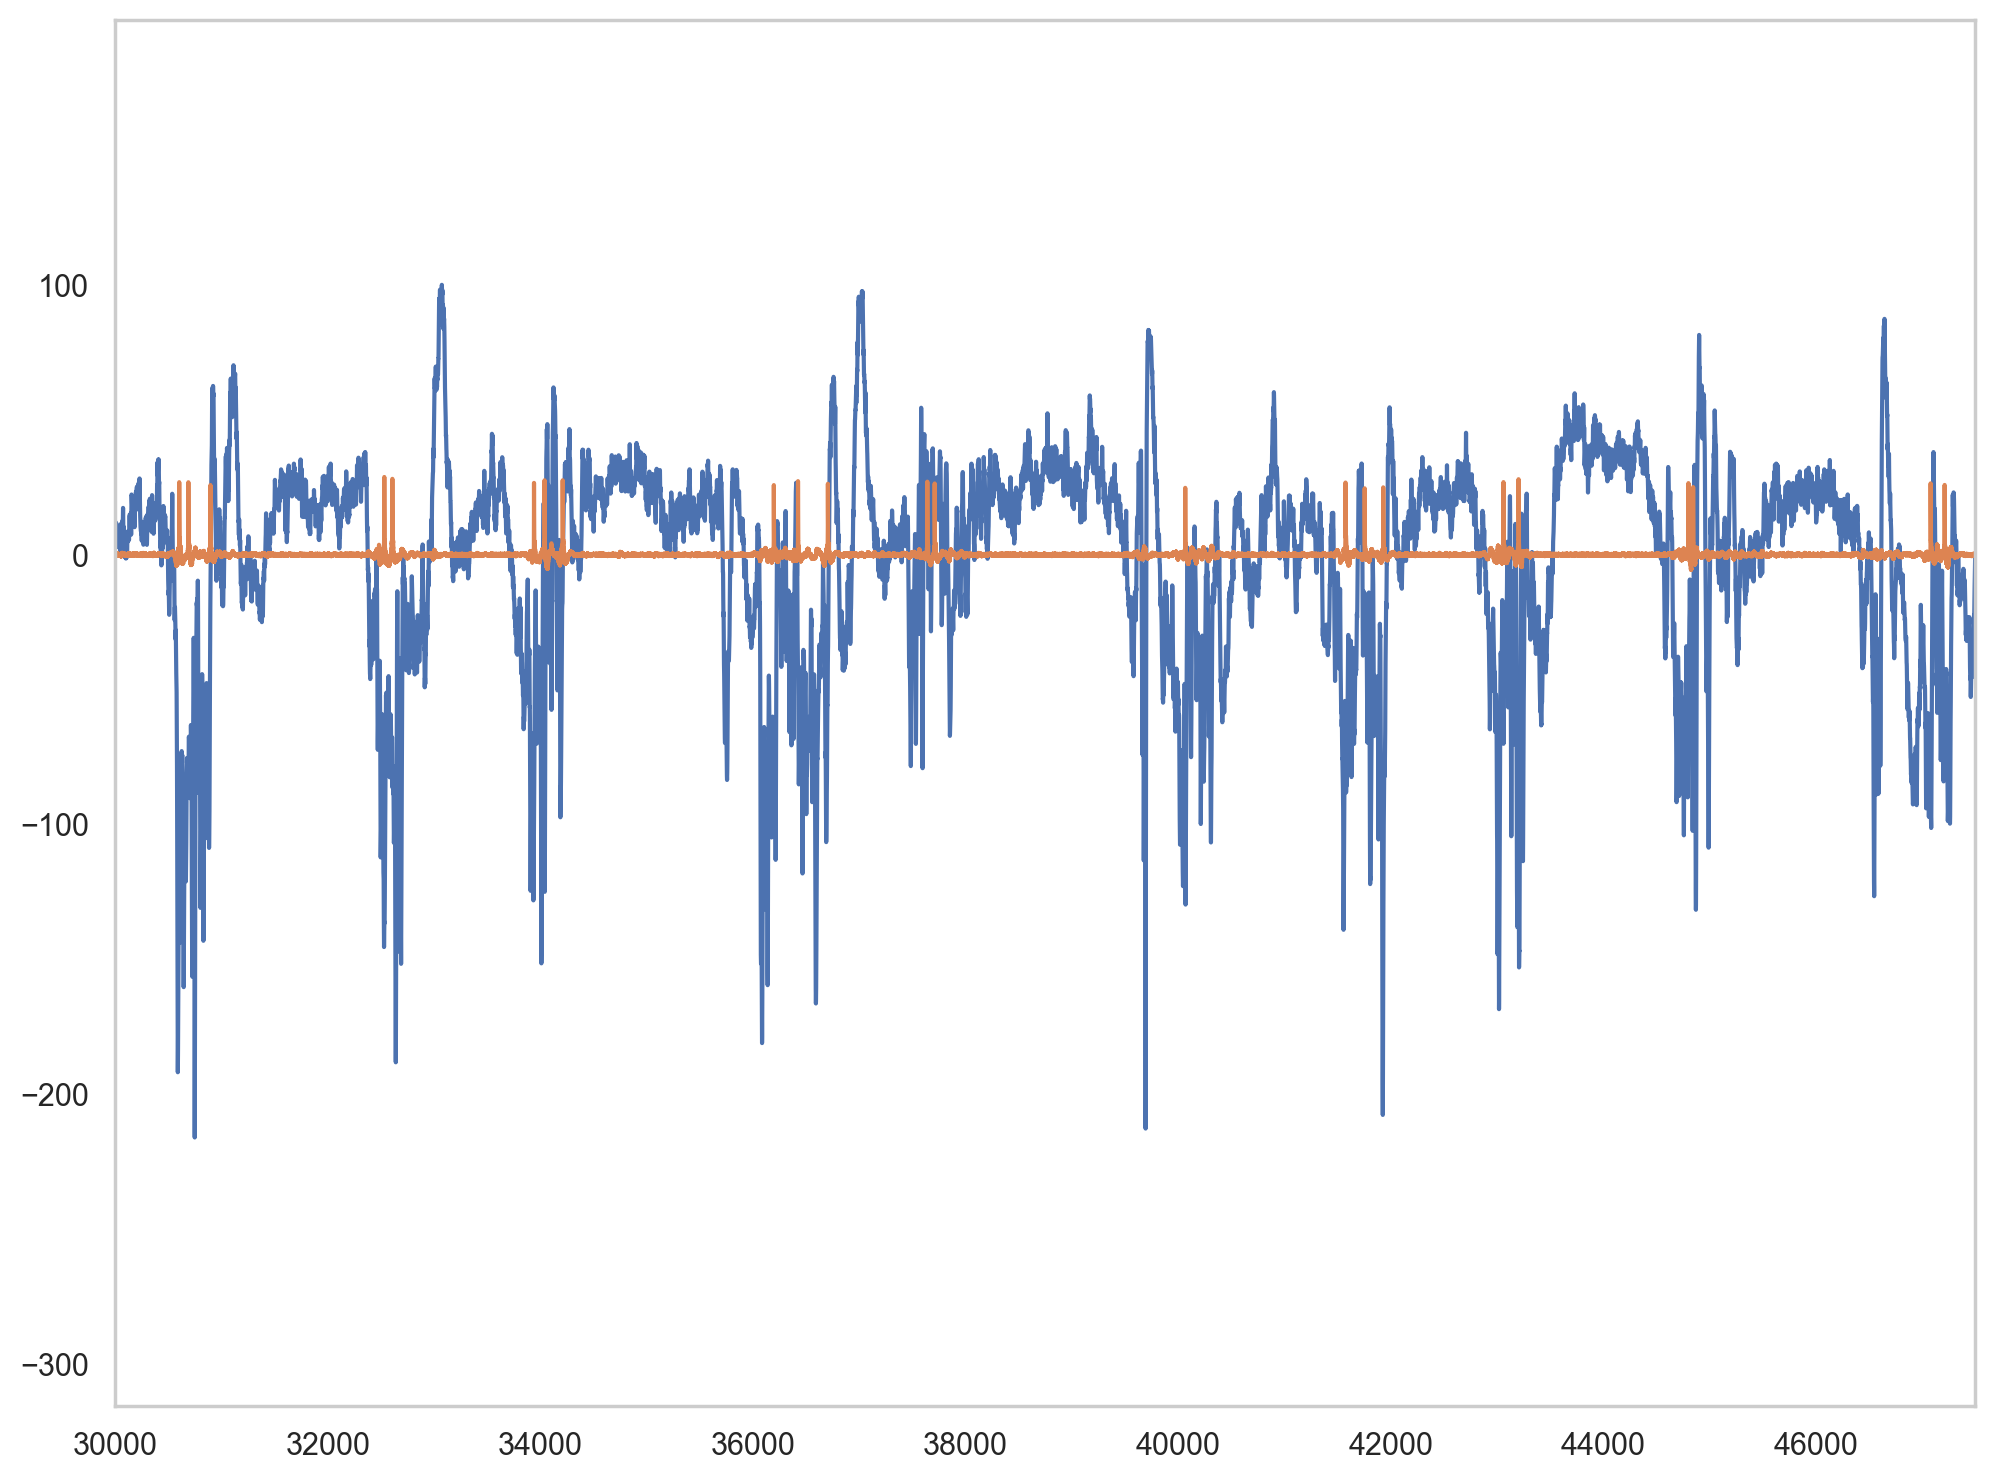

In [17]:
#plot raw LFP and patch data
plt.plot(lfp_times_c42, lfp_filt_c42)
plt.plot(patch_times_c42, patch_filt_c42)
plt.xlim(30000,47500)
plt.show()

#### 1. Filter the signal in +/- 15 Hz around that gamma peak

In [18]:
gamma_peak = 40 #Hz 
gamma_range = [gamma_peak - 15, gamma_peak+15]
#filter LFP data around that range
lfp_filt_gamma_c42 = butter_bandpass(lfp_filt_c42, fs=lfp_fs, filt_freq=gamma_range, order=4)

#### 2. Get the analytic amplitude of the time series 

In [19]:
gamma_amp = amp_by_time(lfp_filt_gamma_c42, lfp_fs, gamma_range)

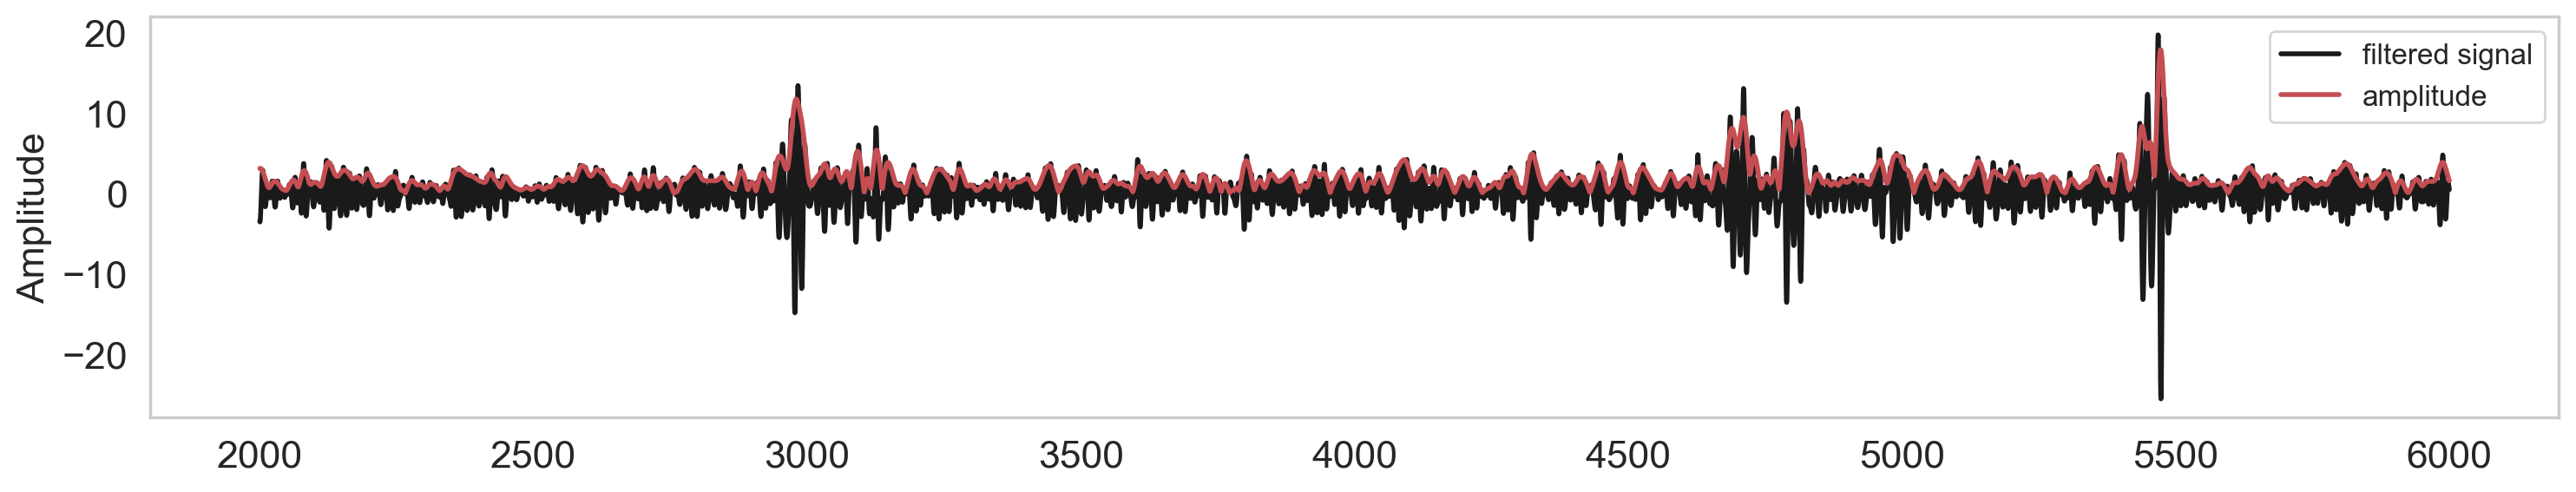

In [20]:
xlim = (2000, 6000)
tidx = np.logical_and(lfp_times_c42 >= xlim[0],lfp_times_c42 < xlim[1])

# Plot the filtered signal and oscillation amplitude
plot_instantaneous_measure(lfp_times_c42[tidx], [lfp_filt_gamma_c42[tidx], gamma_amp[tidx]],
                           measure='amplitude', lw=2, xlabel='',
                           labels=['filtered signal', 'amplitude'])

#### 3. Classify a burst as whenever the gamma analytic amplitude goes above some criterion (3x median, 2std of the mean, whatever), and ends when it drops below another criterion (1.5x mean, 1std of mean)


#### Try 3 different moethods for gamma burst classifcation
#### Method 1: My own code to detect when analytic amplitude goes above some criteria - ignore for now (slower)
#### Method 2: neurodsp burst detection on gamma filtered data
#### Method 3: neurodsp burst detection on unfiltered data 

#### Method 2

In [ ]:
xlim = (4000,200000)
tidx = np.logical_and(lfp_times_c42 >= xlim[0],lfp_times_c42 < xlim[1])

In [ ]:
###Try neurodsp burst detection method 
is_burst_m2 = detect_bursts_dual_threshold(lfp_filt_c42, lfp_fs, dual_thresh=(4, 2), f_range=(gamma_peak - 15, gamma_peak+15))


In [ ]:
plot_bursts(lfp_times_c42[tidx], lfp_filt_gamma_c42[tidx], is_burst_m2[tidx], labels=['Filtered LFP', 'Detected Burst'])


In [ ]:
gamma_bursts_ms_m2 = in_burst_to_burst_range_ms(is_burst_m2)


#### Method 3

In [ ]:
###Try neurodsp burst detection method - trouble shooting this rn - changed f-range to -/+ 10 from 15 
is_burst_m3 = detect_bursts_dual_threshold(lfp_filt_gamma_c42, lfp_fs, dual_thresh=(4, 2), f_range=(gamma_peak - 15, gamma_peak+15))


In [ ]:
plot_bursts(lfp_times_c42[tidx], lfp_filt_gamma_c42[tidx], is_burst_m3[tidx], labels=['Filtered LFP', 'Detected Burst'])


In [ ]:
gamma_bursts_ms_m3 = in_burst_to_burst_range_ms(is_burst_m3)

### Load and analyze extracellular spike data - IGNORE EXTRACELLULAR FOR NOW

In [ ]:

#load npx data
npx_file_dir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/'
npx_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/c42npx_filt.npy'
npx_fs = 30000 # sampling rate
npx_one_ms = int(npx_fs / 1000)
npx_channels = 384
npx_patch_channel = 109


In [31]:
# open and load the data
npx_filt = np.load(npx_path)

In [32]:
npx_times_c42 = np.arange(0, np.shape(npx_filt)[0]) / npx_one_ms # in ms instead of sec"""

In [33]:
"""npx_times_c42 [-1]/60000"""

'npx_times_c42 [-1]/60000'

In [34]:
"""plt.plot(npx_filt[0:100000])"""

'plt.plot(npx_filt[0:100000])'

### Compute patch clamp spike features for cell 42

#### 4. compare the patched spike waveform for spikes that occur during an obvious gamma burst versus those are are obviously not in gamma. We’ll want to confirm this visually, looking at the time series as well.


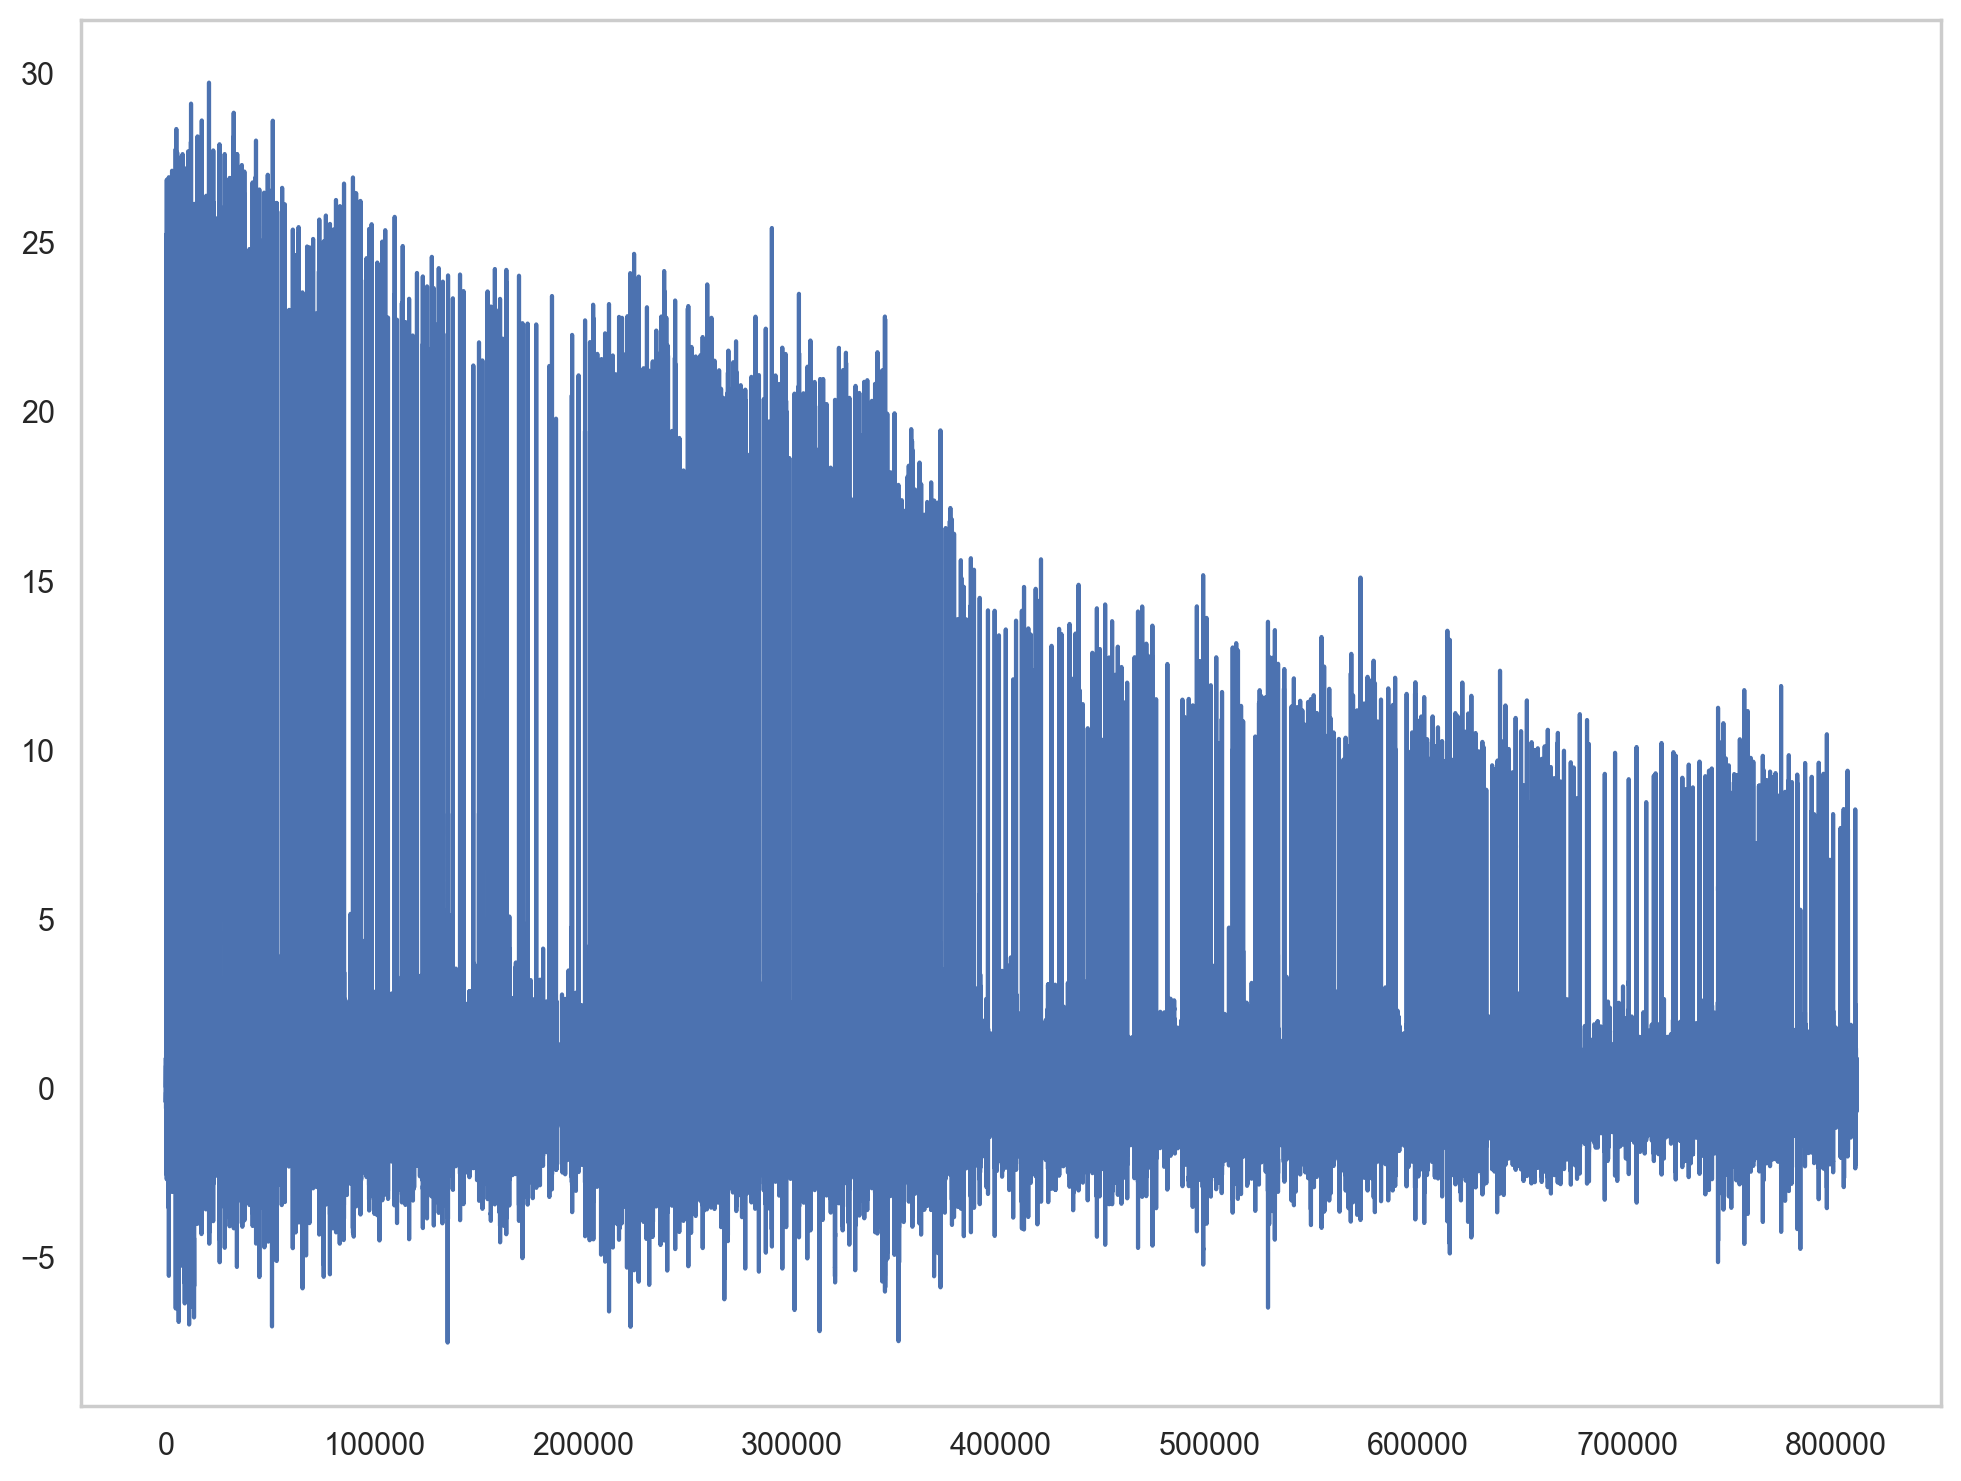

In [39]:
plt.plot(patch_times_c42, patch_filt_c42)

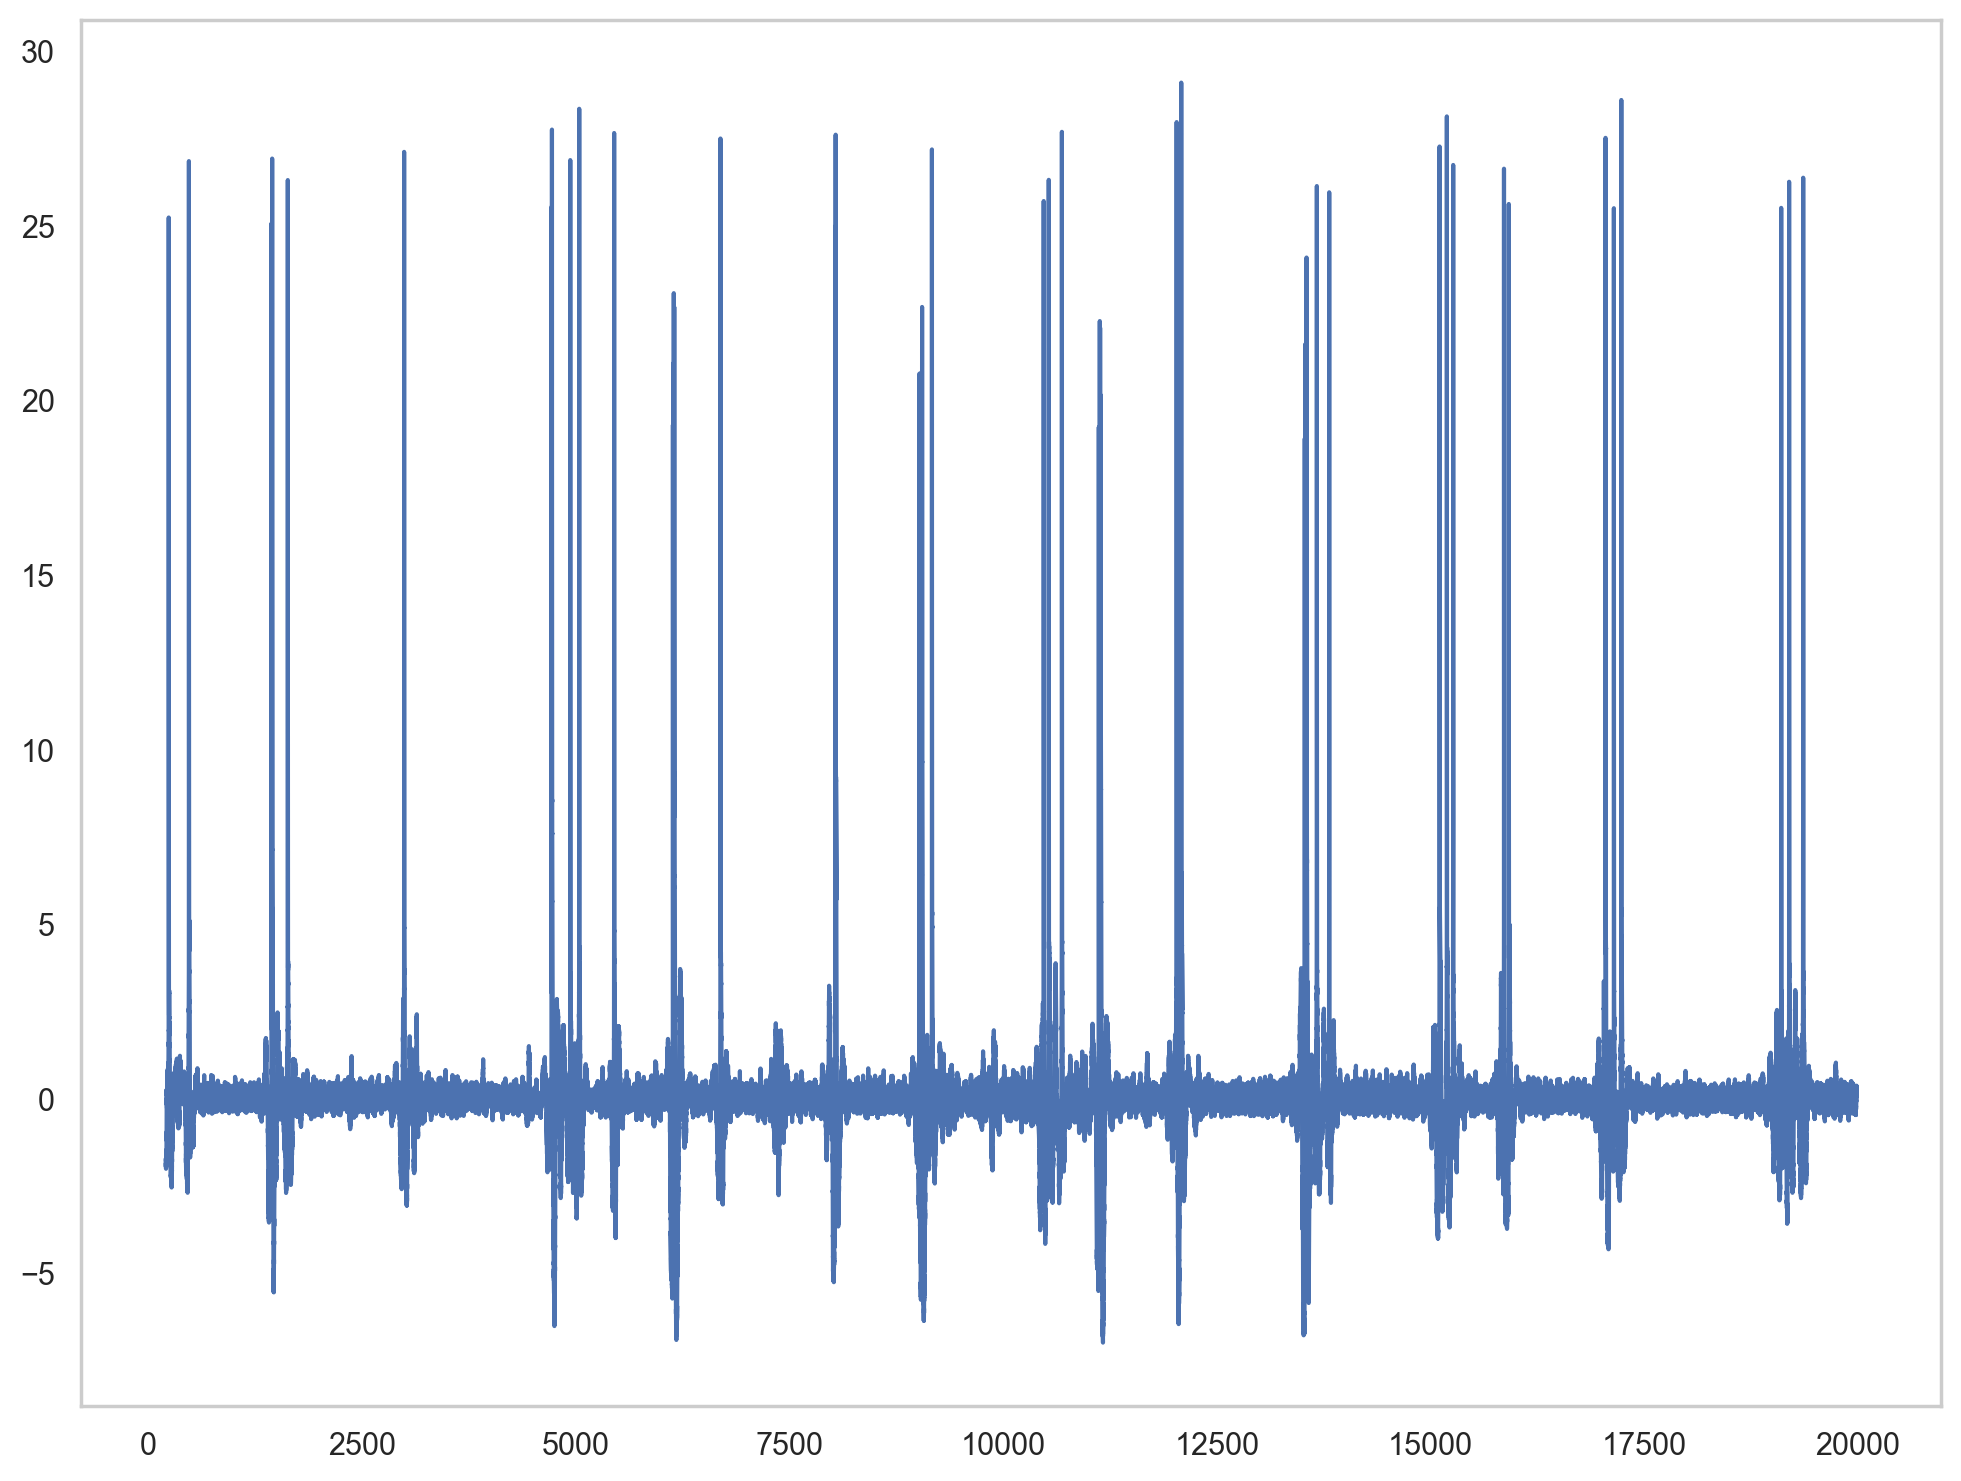

In [40]:
plt.plot(patch_times_c42[10000:1000000], patch_filt_c42[10000:1000000])

In [42]:
sp.df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi,r_squared_ramp,r_squared_exp,LFP_mean,LFP_std
0,0.655520,0.76,2.234912,25.207082,1.24,0.532077,1.323753,2.357226,236.247160,0.847685,0.996917,-50.463271,8.117908
1,0.830898,0.70,3.834110,26.766186,1.14,0.717454,1.616296,4.364779,974.474558,0.951638,0.987640,-62.891947,49.619044
2,0.514807,0.84,3.345557,26.927673,1.54,0.423752,0.981911,6.132088,182.992596,0.821644,0.999190,-64.840335,21.625966
3,1.131318,0.72,3.423346,26.219775,1.14,0.626201,1.488794,3.536553,1361.549677,0.976667,0.996812,37.291949,19.876358
4,1.095346,0.72,3.602710,27.026259,1.20,0.577308,1.179299,3.795708,1729.993696,0.935903,0.999019,-59.894702,15.871402
...,...,...,...,...,...,...,...,...,...,...,...,...,...
621,0.517355,0.70,3.353721,10.312721,1.78,0.165035,0.585853,3.846416,2105.554315,0.877078,0.995158,-3.340474,27.501406
622,-0.909968,1.02,4.727512,11.676022,3.28,0.151212,0.276106,4.721465,1658.247964,0.933486,0.996783,14.903445,24.120644
623,0.095210,1.06,3.676545,11.090664,3.14,-0.015259,0.258909,2.899849,15992.021665,0.072322,0.997072,-20.153100,37.540807
624,-0.175349,1.08,4.097930,11.829634,3.78,0.121415,0.237549,4.137374,21926.827000,0.450267,0.997292,-7.101827,19.448565


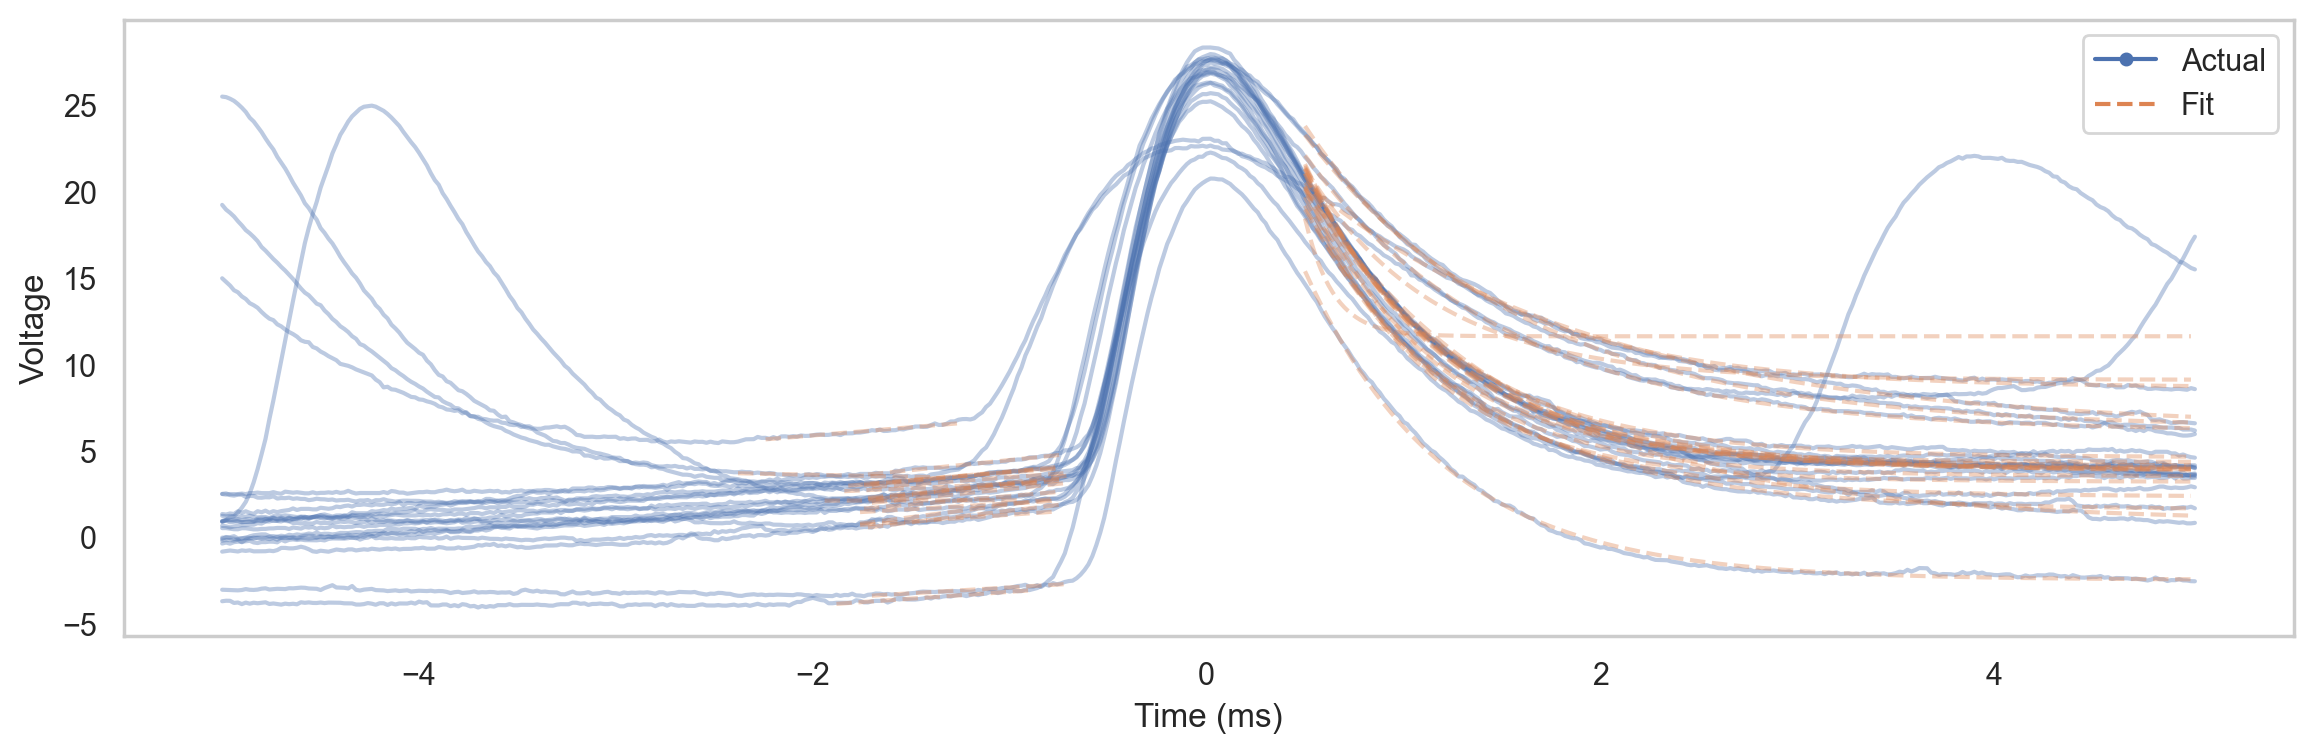

In [43]:
# First 10 fits
sp.plot(inds=np.arange(
    20), mode='full')